## StormQCAModel

In [43]:
from corrqec2.noisemodels import StormQCAModel
from corrqec2.experiments import SurfaceCodeMemory
import numpy as np
import matplotlib.pyplot as plt

In [44]:
def bath_matrix_from_error_matrix(error_matrix):
    return error_matrix != 0

def density_time_series(baths: np.ndarray) -> np.ndarray:
    """
    ρ_t = fraction of sites in state 1 at each time t, averaged over samples.

    baths: (n_samples, n_sites, n_steps)
    returns: (n_steps,)
    """
    n_samples, n_sites, n_steps = baths.shape
    # average over sites -> (n_samples, n_steps)
    rho_t_samples = baths.mean(axis=1)
    # average over samples -> (n_steps,)
    rho_t = rho_t_samples.mean(axis=0)
    return rho_t


def density_stats(baths: np.ndarray, burnin: int = 0) -> dict:
    """
    Steady-state density stats from t >= burnin.

    Returns:
        rho_mean: ⟨ρ⟩
        rho_var: Var(ρ)
        chi: N * Var(ρ)  (susceptibility-like)
    """
    n_samples, n_sites, n_steps = baths.shape
    if burnin >= n_steps:
        raise ValueError("burnin must be < n_steps")

    # keep steps [burnin:]
    baths_cut = baths[:, :, burnin:]                       # (S, N, T')
    rho_t_samples = baths_cut.mean(axis=1)                 # (S, T')
    rho_flat = rho_t_samples.ravel()                       # all samples+times

    rho_mean = float(rho_flat.mean())
    rho_var = float(rho_flat.var())
    chi = n_sites * rho_var
    return {"rho_mean": rho_mean, "rho_var": rho_var, "chi": chi}

def density_autocorrelation(
    baths: np.ndarray,
    max_lag: int,
    burnin: int = 0,
) -> np.ndarray:
    """
    C(τ) = ⟨(ρ_t - ⟨ρ⟩)(ρ_{t+τ} - ⟨ρ⟩)⟩_t,samples.

    baths:   (n_samples, n_sites, n_steps)
    returns: (max_lag+1,) with C[0] = Var(ρ)
    """
    n_samples, n_sites, n_steps = baths.shape
    if burnin >= n_steps:
        raise ValueError("burnin must be < n_steps")

    baths_cut = baths[:, :, burnin:]                 # (S, N, T')
    rho_t_samples = baths_cut.mean(axis=1)           # (S, T')
    # flatten over samples to one long time series
    rho = rho_t_samples.ravel().astype(np.float64)   # (S*T',)
    rho -= rho.mean()

    C = np.empty(max_lag + 1, dtype=np.float64)
    N = rho.shape[0]
    for tau in range(max_lag + 1):
        if tau == 0:
            C[tau] = np.mean(rho * rho)
        else:
            C[tau] = np.mean(rho[:-tau] * rho[tau:])
    return C / C[0]

def binder_cumulant(baths: np.ndarray, burnin: int = 0) -> float:
    """
    Binder cumulant U of σ = 2s-1 spins.

    U = 1 - ⟨m^4⟩ / (3 ⟨m^2⟩^2),
    where m = (1/N) ∑_i σ_i.

    baths: (n_samples, n_sites, n_steps)
    """
    n_samples, n_sites, n_steps = baths.shape
    if burnin >= n_steps:
        raise ValueError("burnin must be < n_steps")

    baths_cut = baths[:, :, burnin:]            # (S, N, T')
    spins = 2 * baths_cut - 1                   # σ ∈ {-1, +1}
    m_t_samples = spins.mean(axis=1)            # (S, T') magnetisation per sample/time

    m_flat = m_t_samples.ravel()
    m2 = np.mean(m_flat**2)
    m4 = np.mean(m_flat**4)
    if m2 == 0.0:
        return 0.0
    U = 1.0 - m4 / (3.0 * m2 * m2)
    return float(U)

In [ ]:
def sample_error_matrix(distance, rounds, shots, theta, a, b, outdir):
    experiment = SurfaceCodeMemory(distance=distance, rounds=rounds, basis='Z')
    model_params = {
        "a": a,
        "b": b,
        "emissions": [[1, 0, 0, 0], [0, 1 / 3, 1 / 3, 1 / 3]],  # emission probabilities for calm and storm states,
        "theta": theta,
    }
    model = StormQCAModel(model_params)
    error_matrix = model.gen_error_matrix(experiment, n_samples=shots)
    return error_matrix

In [45]:
distance = 5
burnin = 1000
experiment = SurfaceCodeMemory(distance=distance, rounds=1000000, basis='Z')

model_params = {
    "a": 0.0001,  # transition prob. from calm state 0 to storm state 1
    "b": 0.5,  # transition prob. from storm state 1 to calm state 0
    "emissions": [[1, 0, 0, 0], [0, 1 / 3, 1 / 3, 1 / 3]],  # emission probabilities for calm and storm states,
}

thetas = np.linspace(np.pi*0, np.pi*1, 5)
means = []
phis = []
autocorrs = []
binders = []
for theta in thetas:
    model_params["theta"] = theta
    model = StormQCAModel(model_params)
    error_matrix = model.gen_error_matrix(experiment, n_samples=1)
    baths = bath_matrix_from_error_matrix(error_matrix)
    stats = density_stats(baths, burnin=burnin)
    autocorr = density_autocorrelation(baths, max_lag=50, burnin=burnin)
    means.append(stats["rho_mean"])
    phis.append(stats["chi"])
    autocorrs.append(autocorr)
    binders.append(binder_cumulant(baths, burnin=burnin))
    # print(f"theta={theta:.2f}: {stats}")

In [99]:
b = error_matrix.astype(np.uint8)
packed = np.packbits(b, axis=0)
np.savez_compressed("bitpacked.npz", packed)

In [70]:
np.save("error_matrix_int.npy", error_matrix)
np.savez_compressed("error_matrix.npz", error_matrix)
error_matrix_bool = error_matrix.astype(np.bool)
np.save("error_matrix_bool.npy", error_matrix_bool)
np.savez_compressed("error_matrix_bool.npz", error_matrix_bool)

Text(0.5, 1.0, 'Distance 5, Rounds 1000000, Burn-in 1000')

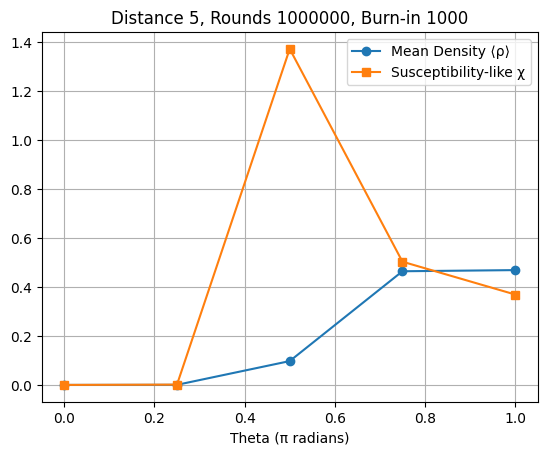

In [46]:
fig, ax = plt.subplots()

thetas = [theta / np.pi for theta in thetas]
ax.plot(thetas, means, marker='o', label='Mean Density ⟨ρ⟩')
ax.plot(thetas, phis, marker='s', label='Susceptibility-like χ')
ax.grid(True)
ax.set_xlabel('Theta (π radians)')
ax.legend()
ax.set_title(f'Distance {distance}, Rounds {experiment.rounds}, Burn-in {burnin}')

Text(0.5, 1.0, 'Distance 5 autocorrelations')

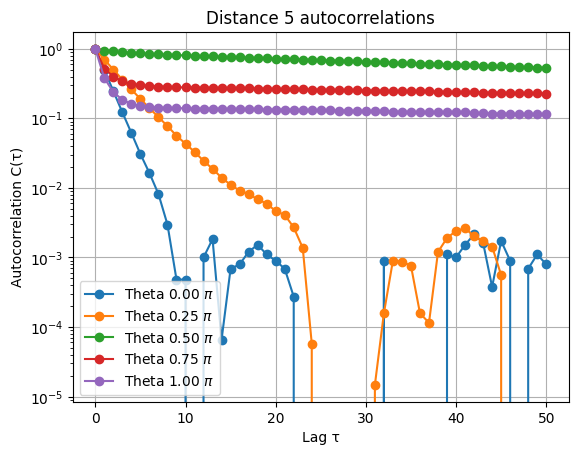

In [47]:
fig2, ax2 = plt.subplots()

taus = np.arange(len(autocorrs[0]))
for i, ac in enumerate(autocorrs):
    ax2.plot(taus, ac, marker='o', label=f'Theta {thetas[i]:.2f} $\\pi$')

ax2.set_xlabel('Lag τ')
ax2.set_ylabel('Autocorrelation C(τ)')
ax2.semilogy()
ax2.grid(True)
ax2.legend()
ax2.set_title(f'Distance {distance} autocorrelations')

Text(0.5, 1.0, 'Distance 5 Binder Cumulant')

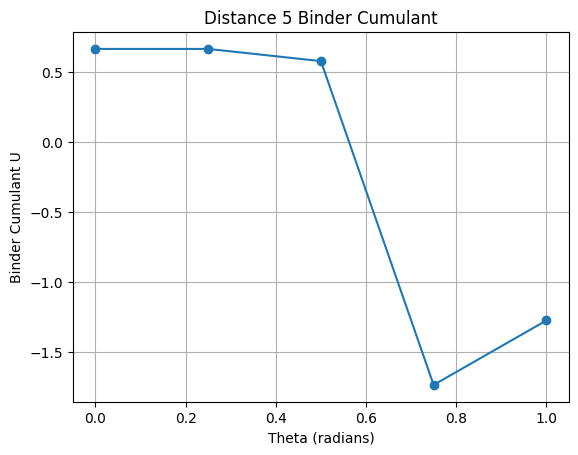

In [48]:
fig3, ax3 = plt.subplots()
ax3.plot(thetas, binders, marker='o', label='Binder Cumulant U')
ax3.grid(True)
ax3.set_xlabel('Theta (radians)')
ax3.set_ylabel('Binder Cumulant U')
ax3.set_title(f'Distance {distance} Binder Cumulant')